# 03 — Study design flowchart

Three-lane layout:
1. **Top: HELD-OUT VALIDATION SETS** — PDB (orange/brown, class I+II) and
   CRESTA (purple, class II only)
2. **Middle: TRAINING SOURCE** — IEDB (blue), 5-step pipeline ending in PTI-PAE
3. **Bottom: VALIDATION** — AF3 classifier (dark navy) → PDB 0.92 → CRESTA 0.78

No external data needed — all counts hardcoded from Methods.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Color palette
INK         = "#1f1f1f"
SUBTLE      = "#666666"
PDB_DARK    = "#8a4116"; PDB_MID = "#c46a1f"; PDB_FILL = "#fbe6d4"; PDB_TINT = "#fdf2e8"
CR_DARK     = "#5b2a7e"; CR_MID  = "#7a3da3"; CR_FILL  = "#e9d9f5"; CR_TINT  = "#f5ecfa"
IEDB_DARK   = "#1f3a68"; IEDB_MID = "#2e5da0"; IEDB_FILL = "#d6e3f4"; IEDB_TINT = "#eaf1f9"
NEG_DARK    = "#a23a3a"; NEG_FILL = "#f9e0e0"
CLF_DARK    = "#1c2735"
SECTION_LBL = "#b07a1d"

def rounded_box(ax, x, y, w, h, face, edge, lw=1.5, alpha=1.0, zorder=2):
    ax.add_patch(FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.0,rounding_size=2.5",
        facecolor=face, edgecolor=edge, linewidth=lw, alpha=alpha, zorder=zorder))

def arrow(ax, x1, y1, x2, y2, color=INK, lw=1.6, head=12, ls='-', zorder=4):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2),
        arrowstyle='-|>', mutation_scale=head,
        color=color, linewidth=lw, linestyle=ls, zorder=zorder))

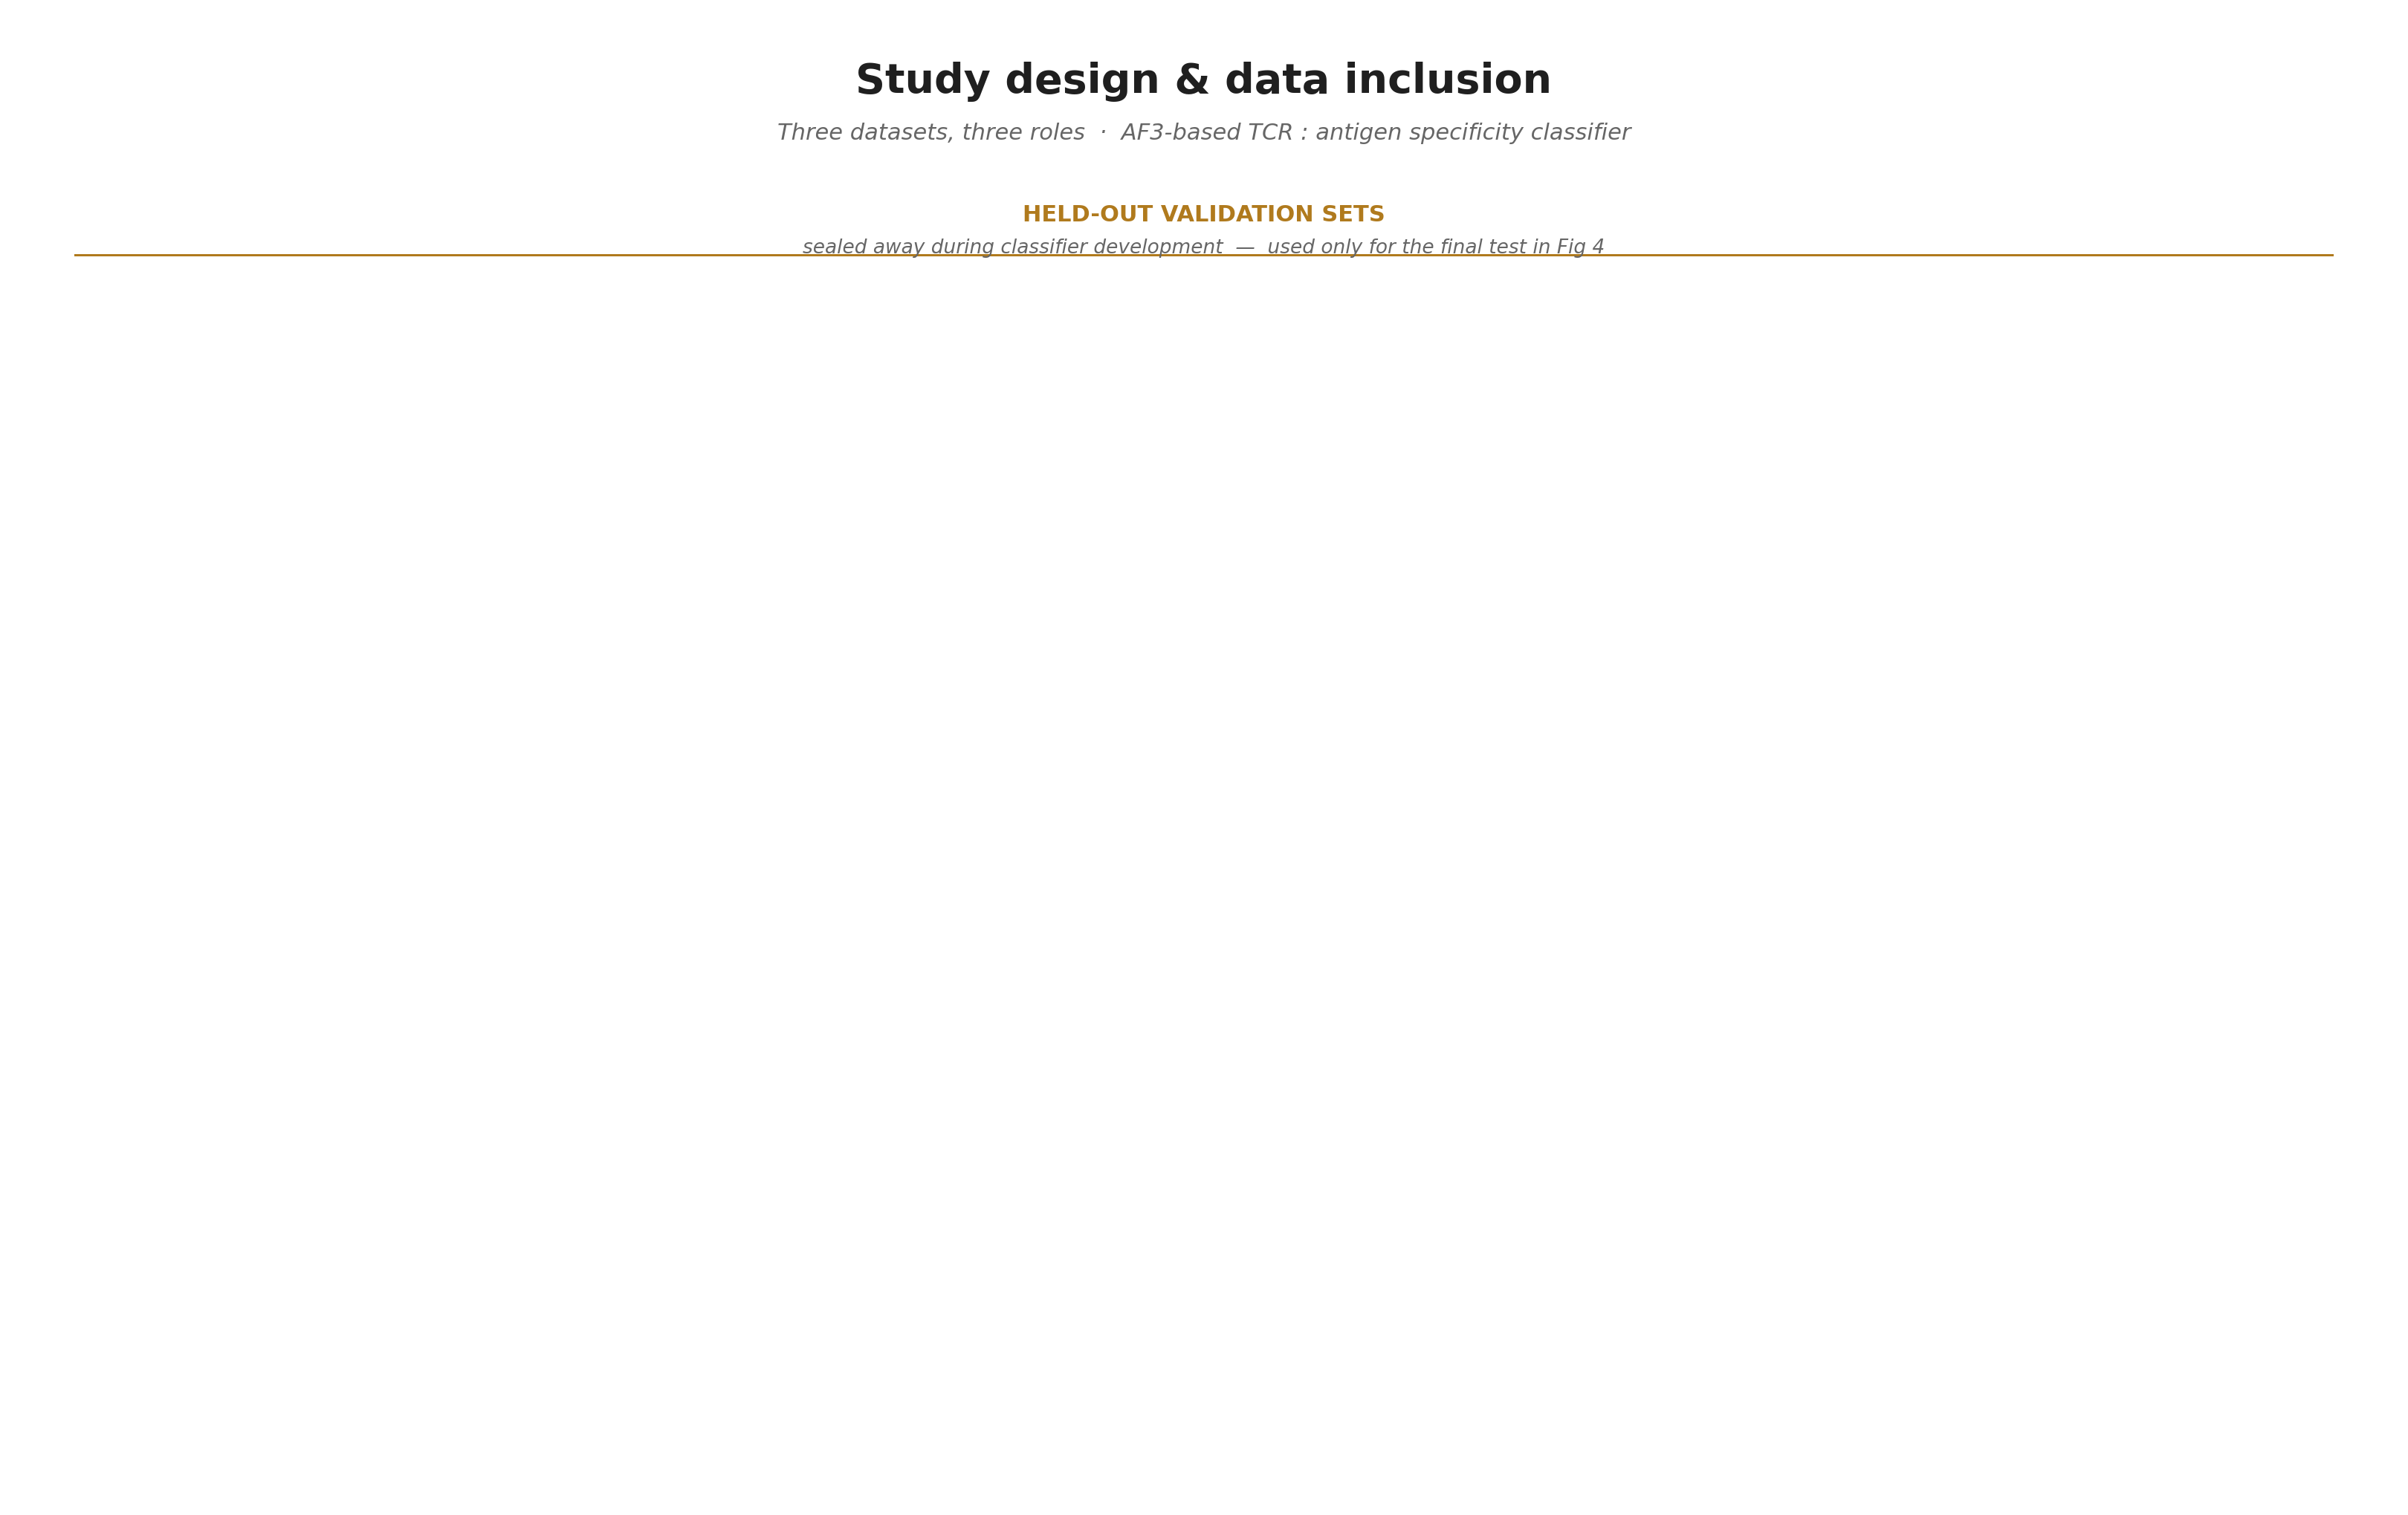

In [2]:
fig = plt.figure(figsize=(16, 10), dpi=200)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 160); ax.set_ylim(0, 100); ax.axis('off')

# Title
ax.text(80, 95.5, 'Study design & data inclusion', ha='center', va='center',
        fontsize=20, fontweight='bold', color=INK)
ax.text(80, 92, 'Three datasets, three roles  ·  AF3-based TCR : antigen specificity classifier',
        ha='center', va='center', fontsize=11, fontstyle='italic', color=SUBTLE)

# Top label
ax.text(80, 86.5, 'HELD-OUT VALIDATION SETS', ha='center', va='center',
        fontsize=11, fontweight='bold', color=SECTION_LBL)
ax.text(80, 84.3, 'sealed away during classifier development  —  used only for the final test in Fig 4',
        ha='center', va='center', fontsize=9.5, fontstyle='italic', color=SUBTLE)
ax.add_patch(plt.Rectangle((4, 83.7), 152, 0.15, facecolor=SECTION_LBL, zorder=1))

In [3]:
# PDB lane (LEFT)
pdb_box_x, pdb_box_y, pdb_box_w, pdb_box_h = 4, 56, 78, 26
rounded_box(ax, pdb_box_x, pdb_box_y, pdb_box_w, pdb_box_h, face='white', edge=PDB_DARK, lw=2.0)
rounded_box(ax, pdb_box_x, pdb_box_y + pdb_box_h - 6, pdb_box_w, 6,
            face=PDB_DARK, edge=PDB_DARK, lw=2.0, zorder=3)

ax.text(pdb_box_x + 2, pdb_box_y + pdb_box_h - 3, 'PDB', ha='left', va='center',
        fontsize=15, fontweight='bold', color='white', zorder=5)
ax.text(pdb_box_x + 10.5, pdb_box_y + pdb_box_h - 2.4,
        '(structures confirmed via STCRDab)', ha='left', va='center',
        fontsize=9, fontstyle='italic', color='white', zorder=5)
ax.text(pdb_box_x + 2, pdb_box_y + pdb_box_h - 5,
        'Solved MHC:peptide:TCR crystal structures  ·  partitioned by AF3 training cutoff',
        ha='left', va='center', fontsize=8, fontstyle='italic', color='white', zorder=5)
ax.text(pdb_box_x + pdb_box_w - 2, pdb_box_y + pdb_box_h - 3, 'CLASS I + II',
        ha='right', va='center', fontsize=9, fontweight='bold', color='white', zorder=5)

# Fig 1 chip
chip_x = pdb_box_x + 4; chip_y = pdb_box_y + 15.5
rounded_box(ax, chip_x, chip_y, 24, 3.5, face='white', edge=PDB_MID, lw=1.1)
ax.text(chip_x + 12, chip_y + 1.75, 'Fig 1 — structural benchmarking',
        ha='center', va='center', fontsize=9, color=PDB_DARK, fontweight='bold')

# Three sub-boxes
bx, by, bw, bh = pdb_box_x + 4, pdb_box_y + 4, 18, 12
rounded_box(ax, bx, by, bw, bh, face=PDB_TINT, edge=PDB_MID, lw=1.2)
ax.text(bx + bw/2, by + bh - 2.5, '130 triads', ha='center', va='center',
        fontsize=13, fontweight='bold', color=PDB_DARK)
ax.text(bx + bw/2, by + bh - 5, 'pre-AF3 cutoff', ha='center', va='center',
        fontsize=8, fontstyle='italic', color=SUBTLE)
ax.text(bx + bw/2, by + bh - 7.5, '89 class I  +  41 class II',
        ha='center', va='center', fontsize=8.5, color=INK)
ax.text(bx + bw/2, by + bh - 9.5, '(in AF3 training data)',
        ha='center', va='center', fontsize=7.5, fontstyle='italic', color=SUBTLE)

bx2 = bx + bw + 3
rounded_box(ax, bx2, by, bw, bh, face=PDB_TINT, edge=PDB_MID, lw=1.2)
ax.text(bx2 + bw/2, by + bh - 2.5, '21 triads', ha='center', va='center',
        fontsize=13, fontweight='bold', color=PDB_DARK)
ax.text(bx2 + bw/2, by + bh - 5, 'post-AF3 cutoff', ha='center', va='center',
        fontsize=8, fontstyle='italic', color=SUBTLE)
ax.text(bx2 + bw/2, by + bh - 7.5, '16 class I  +  5 class II',
        ha='center', va='center', fontsize=8.5, color=INK)
ax.text(bx2 + bw/2, by + bh - 9.5, '(unseen by AF3 training)',
        ha='center', va='center', fontsize=7.5, fontstyle='italic', color=SUBTLE)

arrow(ax, bx2 + bw + 0.5, by + bh/2, bx2 + bw + 3.5, by + bh/2,
      color=PDB_MID, head=10, lw=1.4)

bx3 = bx2 + bw + 4; bw3 = 24
rounded_box(ax, bx3, by + 2, bw3, bh - 4, face='white', edge=PDB_MID, lw=1.4)
ax.text(bx3 + bw3/2, by + bh - 3, '16 class I', ha='center', va='center',
        fontsize=12, fontweight='bold', color=PDB_DARK)
ax.text(bx3 + bw3/2, by + bh - 5.7, 'held-out for Fig 4a',
        ha='center', va='center', fontsize=8.5, fontstyle='italic', color=SUBTLE)
ax.text(bx3 + bw3/2, by + bh - 8.5, '+  181 non-cognate controls',
        ha='center', va='center', fontsize=8.5, fontweight='bold', color=NEG_DARK)

Text(63.0, 63.5, '+  181 non-cognate controls')

In [4]:
# CRESTA lane (RIGHT)
cr_box_x, cr_box_y, cr_box_w, cr_box_h = 84, 56, 72, 26
rounded_box(ax, cr_box_x, cr_box_y, cr_box_w, cr_box_h, face='white', edge=CR_DARK, lw=2.0)
rounded_box(ax, cr_box_x, cr_box_y + cr_box_h - 6, cr_box_w, 6,
            face=CR_DARK, edge=CR_DARK, lw=2.0, zorder=3)

ax.text(cr_box_x + 2, cr_box_y + cr_box_h - 3, 'CRESTA', ha='left', va='center',
        fontsize=15, fontweight='bold', color='white', zorder=5)
ax.text(cr_box_x + 18, cr_box_y + cr_box_h - 2.4,
        '(antigens never structurally characterized)', ha='left', va='center',
        fontsize=9, fontstyle='italic', color='white', zorder=5)
ax.text(cr_box_x + 2, cr_box_y + cr_box_h - 5,
        'Single-cell barcoded-probe assay (Mead et al. 2024)  ·  M. tuberculosis epitopes',
        ha='left', va='center', fontsize=8, fontstyle='italic', color='white', zorder=5)
ax.text(cr_box_x + cr_box_w - 2, cr_box_y + cr_box_h - 3, 'CLASS II',
        ha='right', va='center', fontsize=9, fontweight='bold', color='white', zorder=5)

cbx, cby, cbw, cbh = cr_box_x + 4, cr_box_y + 4, 16, 9
rounded_box(ax, cbx, cby + 1.5, cbw, cbh, face=CR_TINT, edge=CR_MID, lw=1.2)
ax.text(cbx + cbw/2, cby + cbh - 1, '205 triads', ha='center', va='center',
        fontsize=12, fontweight='bold', color=CR_DARK)
ax.text(cbx + cbw/2, cby + 4, 'starting', ha='center', va='center',
        fontsize=8.5, fontstyle='italic', color=SUBTLE)
ax.text(cbx + cbw/2, cby + 2.5, 'cognate triads', ha='center', va='center',
        fontsize=8.5, fontstyle='italic', color=SUBTLE)

fx = cbx + cbw + 3; fy = cby + cbh/2 + 1
ax.text(fx + 3, fy + 2, 'Filter 1', ha='left', va='center',
        fontsize=11, fontweight='bold', color=CR_DARK)
ax.text(fx + 3, fy - 0.5, 'None of the 8 antigens has prior PDB structures',
        ha='left', va='center', fontsize=8, color=INK)
ax.text(fx + 3, fy - 2, 'no triads removed (none had AF3-training homology)',
        ha='left', va='center', fontsize=8, fontstyle='italic', color=SUBTLE)

arrow(ax, cr_box_x + cr_box_w - 24, fy, cr_box_x + cr_box_w - 19, fy,
      color=CR_MID, head=10, lw=1.4)

chip3_x, chip3_y, chip3_w, chip3_h = cr_box_x + cr_box_w - 18, fy - 1.5, 16, 4
rounded_box(ax, chip3_x, chip3_y, chip3_w, chip3_h, face='white', edge=NEG_DARK, lw=1.4)
ax.text(chip3_x + chip3_w/2, chip3_y + chip3_h/2, '+  1,228', ha='center', va='center',
        fontsize=12, fontweight='bold', color=NEG_DARK)
ax.text(chip3_x + chip3_w/2, chip3_y - 1.5, 'non-cognate', ha='center', va='center',
        fontsize=7.5, fontstyle='italic', color=SUBTLE)
ax.text(chip3_x + chip3_w/2, chip3_y - 3, 'controls added', ha='center', va='center',
        fontsize=7.5, fontstyle='italic', color=SUBTLE)

Text(146.0, 61.0, 'controls added')

In [5]:
# IEDB middle box
iedb_x, iedb_y, iedb_w, iedb_h = 4, 22, 152, 28
rounded_box(ax, iedb_x, iedb_y, iedb_w, iedb_h, face='white', edge=IEDB_DARK, lw=2.0)
rounded_box(ax, iedb_x, iedb_y + iedb_h - 5, iedb_w, 5,
            face=IEDB_DARK, edge=IEDB_DARK, lw=2.0, zorder=3)

ax.text(iedb_x + 2, iedb_y + iedb_h - 2.5, 'IEDB', ha='left', va='center',
        fontsize=15, fontweight='bold', color='white', zorder=5)
ax.text(iedb_x + 14, iedb_y + iedb_h - 2.5,
        'Immune Epitope Database  ·  literature-curated cognate triads, classes I + II',
        ha='left', va='center', fontsize=9.5, fontstyle='italic', color='white', zorder=5)

chip2_x = iedb_x + iedb_w - 28; chip2_y = iedb_y + iedb_h - 4.0
rounded_box(ax, chip2_x, chip2_y, 9, 3, face='white', edge=IEDB_DARK, lw=1.0)
ax.text(chip2_x + 4.5, chip2_y + 1.5, 'Fig 2–3', ha='center', va='center',
        fontsize=8.5, fontweight='bold', color=IEDB_DARK)
ax.text(chip2_x + 18, chip2_y + 1.5, 'TRAINING SOURCE', ha='center', va='center',
        fontsize=9, fontweight='bold', color='white')

# 5 numbered steps
step_y, step_h = iedb_y + 2, iedb_h - 9
step_w = 27.5
step_xs = [iedb_x + 4 + i * (step_w + 1.5) for i in range(5)]
step_titles = ['Start', 'Filter 1', 'Filter 2', '+ Non-cognate', 'Feature selection']
step_subs = [
    'All eligible human triads',
    'Drop look-alikes of AF3-trained PDB structures',
    'Drop look-alikes of held-out PDB / CRESTA',
    'Permuted TCRs as negative controls',
    'Score 59 AF3 features per triad',
]
step_counts = [
    ('9,792 cognate triads', '8,104 class I  ·  1,688 class II'),
    ('9,336',                 '7,711 class I  ·  1,625 class II'),
    ('9,327',                 '7,702 class I  ·  1,625 class II'),
    ('190,653',               '157,025 class I  ·  33,628 class II'),
    ('PTI-PAE',               'selected as the classifier'),
]
step_faces = [IEDB_TINT, 'white', 'white', NEG_FILL, IEDB_TINT]
step_edges = [IEDB_MID,   IEDB_MID, IEDB_MID, NEG_DARK, IEDB_MID]
step_count_colors = [IEDB_DARK, IEDB_DARK, IEDB_DARK, NEG_DARK, IEDB_DARK]

for i, (sx, title, sub, (n_top, n_bot), face, edge, n_col) in enumerate(
        zip(step_xs, step_titles, step_subs, step_counts, step_faces,
            step_edges, step_count_colors)):
    rounded_box(ax, sx, step_y, step_w, step_h, face=face, edge=edge, lw=1.3)
    circle_x = sx + 3.5; circle_y = step_y + step_h - 3
    ax.scatter([circle_x], [circle_y], s=380, color=edge, edgecolors='none', zorder=5)
    ax.text(circle_x, circle_y, str(i + 1), ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=6)
    ax.text(circle_x + 4, circle_y, title, ha='left', va='center',
            fontsize=11, fontweight='bold', color=INK)
    ax.text(sx + step_w / 2, step_y + step_h - 6.5, sub, ha='center', va='center',
            fontsize=8, fontstyle='italic', color=SUBTLE)
    ax.text(sx + step_w / 2, step_y + step_h - 11.5, n_top, ha='center', va='center',
            fontsize=14, fontweight='bold', color=n_col)
    ax.text(sx + step_w / 2, step_y + step_h - 14, n_bot, ha='center', va='center',
            fontsize=8.5, color=INK if i < 4 else SUBTLE,
            fontstyle='italic' if i == 4 else 'normal')

# Step → step arrows
for i in range(4):
    x1 = step_xs[i] + step_w; x2 = step_xs[i + 1]
    y_mid = step_y + step_h / 2 - 1
    arrow(ax, x1 + 0.1, y_mid, x2 - 0.1, y_mid, color=IEDB_MID, head=12, lw=1.5)

# Dashed top → IEDB
arrow(ax, pdb_box_x + 38, pdb_box_y - 0.1, step_xs[2] + step_w / 2 - 2, step_y + step_h + 0.1,
      color=PDB_MID, ls=(0, (5, 3)), head=10, lw=1.2, zorder=3)
arrow(ax, cr_box_x + 25, cr_box_y - 0.1, step_xs[2] + step_w / 2 + 2, step_y + step_h + 0.1,
      color=CR_MID, ls=(0, (5, 3)), head=10, lw=1.2, zorder=3)
ax.text(80, 53.5, 'held-out sets', ha='center', va='center',
        fontsize=9, fontstyle='italic', color=SUBTLE)
ax.text(80, 52, 'consulted to filter training', ha='center', va='center',
        fontsize=9, fontstyle='italic', color=SUBTLE)

Text(80, 52, 'consulted to filter training')

In [6]:
# Bottom row: VALIDATION
ax.text(4, 18.5, 'VALIDATION', ha='left', va='center',
        fontsize=11, fontweight='bold', color=SECTION_LBL)
ax.text(4, 16.2, 'trained classifier scored on each held-out triad   →   per-antigen AUCs (Fig 4)',
        ha='left', va='center', fontsize=9, fontstyle='italic', color=SUBTLE)
ax.add_patch(plt.Rectangle((4, 15.5), 152, 0.12, facecolor=SECTION_LBL, zorder=1))

# AF3 classifier box
clf_x, clf_y, clf_w, clf_h = 4, 3, 50, 11
rounded_box(ax, clf_x, clf_y, clf_w, clf_h, face=CLF_DARK, edge=CLF_DARK, lw=1.6)
ax.text(clf_x + 6, clf_y + clf_h - 3.5, 'AF3', ha='left', va='center',
        fontsize=18, fontweight='bold', color='white')
ax.text(clf_x + 6, clf_y + clf_h - 6.5, 'PTI-PAE', ha='left', va='center',
        fontsize=11, fontweight='bold', color='white')
ax.text(clf_x + 6, clf_y + clf_h - 9, 'classifier', ha='left', va='center',
        fontsize=9, fontstyle='italic', color='#cccccc')
ax.text(clf_x + 22, clf_y + clf_h - 3, 'trained on IEDB feature\nselection (panel 5)',
        ha='left', va='center', fontsize=8.5, color='white', fontstyle='italic')
ax.text(clf_x + 22, clf_y + clf_h - 7.5, 'scored on each held-out\ntriad → outputs AUCs',
        ha='left', va='center', fontsize=8.5, color='white', fontstyle='italic')

# L-arrow IEDB step 5 → AF3
step5_mid_x = step_xs[4] + step_w / 2
midpoint_y = (step_y - 1 + clf_y + clf_h) / 2
ax.plot([step5_mid_x, step5_mid_x], [step_y - 0.1, midpoint_y], color=IEDB_DARK, lw=1.8, zorder=4)
ax.plot([step5_mid_x, clf_x + 25], [midpoint_y, midpoint_y], color=IEDB_DARK, lw=1.8, zorder=4)
arrow(ax, clf_x + 25, midpoint_y, clf_x + 25, clf_y + clf_h + 0.1,
      color=IEDB_DARK, head=14, lw=1.8, zorder=5)

# PDB validation
val1_x, val1_y, val1_w, val1_h = 60, 3, 45, 11
rounded_box(ax, val1_x, val1_y, val1_w, val1_h, face='white', edge=PDB_DARK, lw=1.8)
ax.text(val1_x + 4, val1_y + val1_h - 2.5, 'PDB', ha='left', va='center',
        fontsize=14, fontweight='bold', color=PDB_DARK)
ax.text(val1_x + 4, val1_y + val1_h - 5, 'validation AUC', ha='left', va='center',
        fontsize=8.5, fontstyle='italic', color=SUBTLE)
ax.text(val1_x + val1_w - 4, val1_y + val1_h - 4, '0.92',
        ha='right', va='center', fontsize=22, fontweight='bold', color=INK)
ax.text(val1_x + val1_w / 2, val1_y + 1.8, 'median, 14 antigens',
        ha='center', va='center', fontsize=8.5, fontstyle='italic', color=SUBTLE)
chip_x, chip_y = val1_x + val1_w - 12, val1_y + val1_h - 1.5
rounded_box(ax, chip_x, chip_y - 1.2, 9, 2.7, face=PDB_TINT, edge=PDB_MID, lw=0.8)
ax.text(chip_x + 4.5, chip_y + 0.15, 'Fig 4a', ha='center', va='center',
        fontsize=8, fontweight='bold', color=PDB_DARK)

arrow(ax, clf_x + clf_w, clf_y + clf_h / 2, val1_x - 0.3, val1_y + val1_h / 2,
      color=PDB_MID, head=12, lw=1.6)

# CRESTA validation
val2_x, val2_y, val2_w, val2_h = 110, 3, 46, 11
rounded_box(ax, val2_x, val2_y, val2_w, val2_h, face='white', edge=CR_DARK, lw=1.8)
ax.text(val2_x + 4, val2_y + val2_h - 2.5, 'CRESTA', ha='left', va='center',
        fontsize=14, fontweight='bold', color=CR_DARK)
ax.text(val2_x + 4, val2_y + val2_h - 5, 'validation AUC', ha='left', va='center',
        fontsize=8.5, fontstyle='italic', color=SUBTLE)
ax.text(val2_x + val2_w - 4, val2_y + val2_h - 4, '0.78',
        ha='right', va='center', fontsize=22, fontweight='bold', color=INK)
ax.text(val2_x + val2_w / 2, val2_y + 1.8, 'median, 8 antigens',
        ha='center', va='center', fontsize=8.5, fontstyle='italic', color=SUBTLE)
chip_x, chip_y = val2_x + val2_w - 12, val2_y + val2_h - 1.5
rounded_box(ax, chip_x, chip_y - 1.2, 9, 2.7, face=CR_TINT, edge=CR_MID, lw=0.8)
ax.text(chip_x + 4.5, chip_y + 0.15, 'Fig 4b', ha='center', va='center',
        fontsize=8, fontweight='bold', color=CR_DARK)

arrow(ax, val1_x + val1_w, val1_y + val1_h / 2, val2_x - 0.3, val2_y + val2_h / 2,
      color=CR_MID, head=12, lw=1.6)

# L-shaped dashed back-arrows (around outside of IEDB)
L_left = 1.5
ax.plot([L_left, L_left], [val1_y + val1_h / 2, pdb_box_y + 2],
        color=PDB_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
ax.plot([L_left, val1_x - 0.1], [val1_y + val1_h / 2, val1_y + val1_h / 2],
        color=PDB_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
ax.plot([L_left, pdb_box_x + 0.1], [pdb_box_y + 2, pdb_box_y + 2],
        color=PDB_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
arrow(ax, L_left + 0.1, pdb_box_y + 2, pdb_box_x + 0.1, pdb_box_y + 2,
      color=PDB_MID, ls=(0, (5, 3)), head=10, lw=1.2, zorder=2)

L_right = 158.5
ax.plot([L_right, L_right], [val2_y + val2_h / 2, cr_box_y + 2],
        color=CR_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
ax.plot([val2_x + val2_w + 0.1, L_right], [val2_y + val2_h / 2, val2_y + val2_h / 2],
        color=CR_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
ax.plot([cr_box_x + cr_box_w - 0.1, L_right], [cr_box_y + 2, cr_box_y + 2],
        color=CR_MID, linestyle=(0, (5, 3)), lw=1.2, zorder=2)
arrow(ax, L_right - 0.1, cr_box_y + 2, cr_box_x + cr_box_w - 0.1, cr_box_y + 2,
      color=CR_MID, ls=(0, (5, 3)), head=10, lw=1.2, zorder=2)

ax.text(4, 0.8, 'Woods et al — in revision', ha='left', va='center',
        fontsize=10, fontstyle='italic', color=SUBTLE)

fig.savefig('study_design_flowchart.png', dpi=300, bbox_inches='tight')
print('Saved: study_design_flowchart.png')
plt.show()

Saved: study_design_flowchart.png
